In [2]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from src.medal.eval_utils import load_and_split, get_teacher_embeddings
from src.medal.core import AutoEncoder
import torch
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-11 09:53:23,992	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-11 09:53:24,441	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            # match training!
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model


def plot_single_param_recon(student_embed, per_sample_recon, labels, 
                            student_embed_test = None, per_sample_recon_test = None, test_labels = None, 
                            fig = None, axes = None, palette = None, cmap = None, norm = None, plot_legend=False,
                            **fig_kwargs):
    if plot_legend:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=True, palette=palette)
        handles, labels = axes[0].get_legend_handles_labels()
        if getattr(axes[0], "legend_", None) is not None:
            axes[0].legend_.remove()

        # make one shared legend for the whole figure
        fig.legend(
            handles, labels,
            **fig_kwargs
        )
    else:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=False, palette=palette)
    sns.scatterplot(
        x=student_embed[:, 0].detach().numpy(), y=student_embed[:, 1].detach().numpy(),
        hue=per_sample_recon,
        palette=cmap, hue_norm=norm,
        s=8,legend=False, rasterized=True,
        ax=axes[1], 
    )
    if len(axes) == 4:
        sns.scatterplot(x=student_embed_test[:, 0].detach().numpy(), 
                        y=student_embed_test[:, 1].detach().numpy(),  
                        ax=axes[2], hue=test_labels, s=4, marker="x",linewidth=0.5, legend=False, alpha=1, palette=palette)
        sns.scatterplot(
            x=student_embed_test[:, 0].detach().numpy(), y=student_embed_test[:, 1].detach().numpy(),
            hue=per_sample_recon_test,
            palette=cmap, hue_norm=norm,marker="x",
            s=4, legend=False, rasterized=True,
            ax=axes[3], alpha=1, linewidth=0.5,
        )

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

In [4]:
X_og, X_test, y_og, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

In [5]:
macaque_umap_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/macaque_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/macaque/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
            val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s})
        
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_46891/1580406936.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

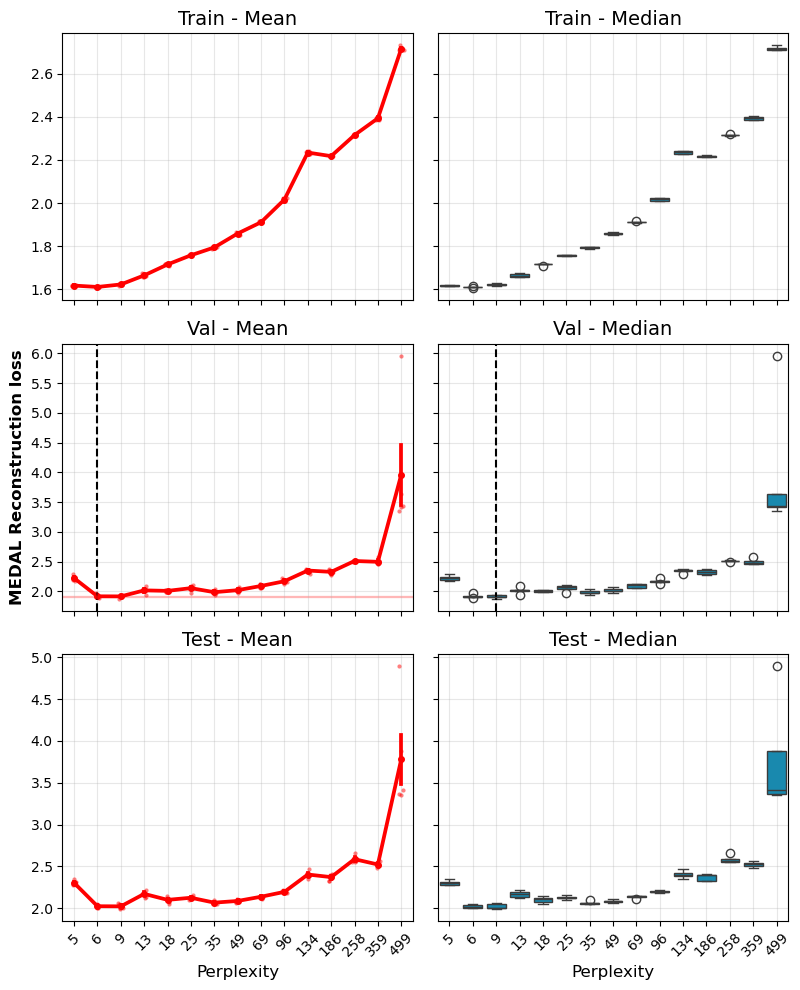

In [6]:
analysis = pd.DataFrame(macaque_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
test_stats = analysis[analysis.split == "Val"].groupby('n_neighbors')['recon_loss'].agg(['mean', 'median', 'sem'])
tsne_argmin_mean = test_stats['mean'].idxmin()
tsne_argmin_median = test_stats['median'].idxmin()
tsne_one_std_range = (test_stats.loc[tsne_argmin_mean, "mean"] - test_stats.loc[tsne_argmin_mean, "sem"], 
                test_stats.loc[tsne_argmin_mean, "mean"] + test_stats.loc[tsne_argmin_mean, "sem"])
tsne_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= tsne_one_std_range[1]) & 
                                           (test_stats['mean'] >= tsne_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 10), sharey='row', sharex=True)
for i, split in enumerate(['Train','Val', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Perplexity", fontsize=12)
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Val":
        ax_point.axvline(x=test_stats.index.get_loc(tsne_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    tsne_one_std_range[0], 
    tsne_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
)
axes[1,0].set_xlim(-0.5,14.5)
axes[1,0].set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()